In [57]:
import math
class Val:
    def __init__(self, val, parents = ()):
        self.value = val
        self.grad = 0
        
        self._parents = set(parents)
        self._backward = lambda: None

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._parents:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __add__(self, other):
        other = other if isinstance(other, Val) else Val(other)
        out = Val(self.value + other.value, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Val) else Val(other)
        out = Val(self.value * other.value, (self, other))

        def _backward():
            self.grad += other.value * out.grad
            other.grad += self.value * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Val(self.value**other, (self,))

        def _backward():
            self.grad += (other * self.value**(other-1)) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        e = math.exp(self.value)
        out = Val(e, (self,))
        def _backward():
            self.grad += e * out.grad
        out._backward = _backward
        return out
    
    def noop(self):
        return self
            
    def sigmoid(self):
        return 1 / (1 + (-self).exp())

    def tanh(self):
        e_pos = self.exp()
        e_neg = (-self).exp()
        return (e_pos - e_neg) / (e_pos + e_neg)
        
    def relu(self):
        out = Val(0 if self.value < 0 else self.value, (self,))

        def _backward():
            self.grad += (out.value > 0) * out.grad
        out._backward = _backward

        return out

    def lrelu(self):
        out = Val(0.01 * self.value if self.value < 0 else self.value, (self,))

        def _backward():
            self.grad += (1.0 if out.value > 0 else 0.01)  * out.grad
        out._backward = _backward

        return out

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Val(data={self.value}, grad={self.grad})"

In [2]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

In [3]:
def call_method(o, name):
    return getattr(o, name)()
    

In [18]:
import random
class Neuron(Module):

    def __init__(self, nin, act_fn = "noop"):
        self.w = [Val(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Val(0)
        self.act_fn = act_fn

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return call_method(act, self.act_fn)

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{self.act_fn}Neuron({len(self.w)})"

In [9]:
class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

In [16]:
class MLP(Module):

    def __init__(self, nin, nouts, act_fn="noop", exit_act_fn="noop"):
        sz = [nin] + nouts
        self.layers = [
            Layer(
                sz[i],
                sz[i+1],
                act_fn = (act_fn if i!=len(nouts)-1 else exit_act_fn),
            )
            for i in range(len(nouts))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [20]:
xs = [
    (0,0),
    (0,	1),
    (1,	0),
    (1,	1),
]
ys = [
    0,
    1,
    1,
    0,
]


In [59]:
def train(net, epoch = 20, lr = .01):
    losses = []
    for e in range(epoch):
        # fwd
        ypred = [net(x) for x in xs]
        loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
        losses.append(loss)
        # zero grad
        net.zero_grad()
        # backwd 
        loss.backward()
        # train
        for p in net.parameters():
            p.value -= lr * p.grad
    return losses



In [43]:

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 


Matplotlib is building the font cache; this may take a moment.


In [93]:
xor_sig = MLP(nin=2, nouts=[8, 1], act_fn="sigmoid", exit_act_fn="sigmoid")
xor_tan = MLP(nin=2, nouts=[2, 1], act_fn="tanh", exit_act_fn="sigmoid")
xor_relu = MLP(nin=2, nouts=[8, 1], act_fn="relu", exit_act_fn="sigmoid")
xor_lrelu = MLP(nin=2, nouts=[8, 1], act_fn="lrelu", exit_act_fn="sigmoid")
xor_sig, xor_tan, xor_relu, xor_lrelu

(MLP of [Layer of [sigmoidNeuron(2), sigmoidNeuron(2), sigmoidNeuron(2), sigmoidNeuron(2), sigmoidNeuron(2), sigmoidNeuron(2), sigmoidNeuron(2), sigmoidNeuron(2)], Layer of [sigmoidNeuron(8)]],
 MLP of [Layer of [tanhNeuron(2), tanhNeuron(2)], Layer of [sigmoidNeuron(2)]],
 MLP of [Layer of [reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2)], Layer of [sigmoidNeuron(8)]],
 MLP of [Layer of [lreluNeuron(2), lreluNeuron(2), lreluNeuron(2), lreluNeuron(2), lreluNeuron(2), lreluNeuron(2), lreluNeuron(2), lreluNeuron(2)], Layer of [sigmoidNeuron(8)]])

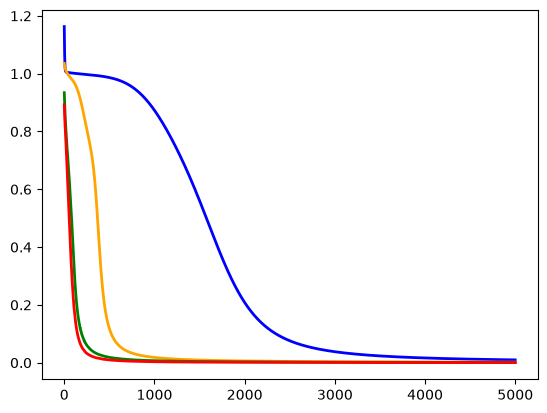

In [94]:
EPOCH = 5000
LR = .1
loss_sigmoid = train(xor_sig, EPOCH, LR)
loss_tanh = train(xor_tan, EPOCH, LR)
loss_relu = train(xor_relu, EPOCH, LR)
loss_lrelu = train(xor_lrelu, EPOCH, LR)

plt.plot([l.value for l in loss_sigmoid], label="Sigmoid", color="blue", linewidth=2)
plt.plot([l.value for l in loss_tanh], label="Tanh", color="orange", linewidth=2)
plt.plot([l.value for l in loss_relu], label="ReLU", color="green", linewidth=2)
plt.plot([l.value for l in loss_lrelu], label="Leaky ReLU", color="red", linewidth=2)
plt.show()

In [95]:
loss_sigmoid[-1], loss_tanh[-1], loss_relu[-1], loss_lrelu[-1]


(Val(data=0.009795783187752368, grad=1),
 Val(data=0.0019290163909411288, grad=1),
 Val(data=0.0009886202698310507, grad=1),
 Val(data=0.00043818786563817826, grad=1))

In [92]:
sig_pred = [xor_sig(x) for x in xs]
tan_pred = [xor_tan(x) for x in xs]
rel_pred = [xor_relu(x) for x in xs]
lrel_pred = [xor_lrelu(x) for x in xs]

print(sig_pred)
print(tan_pred)
print(rel_pred)
print(lrel_pred)

[Val(data=0.018006689330904945, grad=0), Val(data=0.9744949924364246, grad=0), Val(data=0.9740180870408741, grad=0), Val(data=0.03012599530054856, grad=0)]
[Val(data=0.016718250911283365, grad=0), Val(data=0.9873837328626943, grad=0), Val(data=0.9874054269134904, grad=0), Val(data=0.017471927123952003, grad=0)]
[Val(data=0.019286273043110987, grad=0), Val(data=0.9907761228121814, grad=0), Val(data=0.9928326821993004, grad=0), Val(data=0.007145011753474239, grad=0)]
[Val(data=0.008664756806874709, grad=0), Val(data=0.9947856112617963, grad=0), Val(data=0.992469849702655, grad=0), Val(data=0.006197317747303474, grad=0)]
